In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aryanpatel212/cleaned-nyc-taxi-trip-data-2025-sample/NYC_Taxi_Cleaned_Analysis_Ready.csv


In [2]:
# ----- Imports and find the data file -----
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 

# A simple, clean style for all charts.
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BAR_COLOR = "#008ABC"

# Kaggle stores attached datasets under /kaggle/input/.
# This finds the data file automatically so you don't type the exact name.
files = (glob.glob("/kaggle/input/**/*.csv", recursive=True)
         + glob.glob("/kaggle/input/**/*.parquet", recursive=True))

print("Files found:")
for f in files:
    print("  ", f)

data_path = files[0]   # if more than one file is listed, change [0] to the right index
print("\nUsing:", data_path)

Files found:
   /kaggle/input/datasets/aryanpatel212/cleaned-nyc-taxi-trip-data-2025-sample/NYC_Taxi_Cleaned_Analysis_Ready.csv

Using: /kaggle/input/datasets/aryanpatel212/cleaned-nyc-taxi-trip-data-2025-sample/NYC_Taxi_Cleaned_Analysis_Ready.csv


In [3]:
# ----- Load the data -----
df = pd.read_csv("/kaggle/input/datasets/aryanpatel212/cleaned-nyc-taxi-trip-data-2025-sample/NYC_Taxi_Cleaned_Analysis_Ready.csv")

print("=" * 65)
print("   NYC TAXI FARE PREDICTION – MACHINE LEARNING PROJECT")
print("=" * 65)
print(f"\n  Dataset loaded successfully")
print(f"    Shape : {df.shape[0]:,} rows  ×  {df.shape[1]} columns\n")

df.head()

   NYC TAXI FARE PREDICTION – MACHINE LEARNING PROJECT

  Dataset loaded successfully
    Shape : 3,946,698 rows  ×  25 columns



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration_min,speed_mph,pickup_hour,day_of_week,is_weekend
0,2,2025-01-18 20:53:30,2025-01-18 21:00:47,1,0.97,1,N,238,166,1,...,1.0,13.32,0.0,0.0,0.00,7.283333,7.990847,20,Saturday,True
1,1,2025-01-25 11:12:51,2025-01-25 11:17:57,1,0.60,1,N,50,48,2,...,1.0,10.55,2.5,0.0,0.75,5.100000,7.058824,11,Saturday,True
2,1,2025-01-21 15:09:31,2025-01-21 15:19:02,1,0.80,1,N,236,237,1,...,1.0,16.65,2.5,0.0,0.00,9.516667,5.043783,15,Tuesday,False
3,2,2025-01-11 22:25:45,2025-01-11 22:34:22,2,1.93,1,N,231,68,1,...,1.0,20.37,2.5,0.0,0.75,8.616667,13.439072,22,Saturday,True
4,2,2025-01-04 23:37:07,2025-01-04 23:45:58,1,4.44,1,N,137,88,0,...,1.0,35.12,0.0,NaN,0.00,8.850000,30.101695,23,Saturday,True


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3946698 entries, 0 to 3946697
Data columns (total 25 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   RatecodeID             int64  
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  Airport_fee            float64
 19  cbd_congestion_fee     float64
 20  duration_min           float64
 21  speed_mph              float64
 22  pickup_hour       

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration_min,speed_mph,pickup_hour
count,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.189311e+06,3.946698e+06,3.946698e+06,3.946698e+06,3.946698e+06
mean,1.787345e+00,1.233373e+00,3.441244e+00,2.710091e+00,1.620718e+02,1.611536e+02,9.466660e-01,1.936859e+01,1.307855e+00,4.963577e-01,3.028975e+00,5.057680e-01,9.830288e-01,2.813628e+01,1.861057e+00,1.493874e-01,5.504911e-01,1.697423e+01,1.102928e+01,1.420994e+01
std,4.194354e-01,6.595587e-01,4.121952e+00,1.264134e+01,6.562439e+01,7.000420e+01,6.359776e-01,1.576509e+01,1.842253e+00,4.729320e-02,3.787247e+00,1.986163e+00,1.288213e-01,1.988695e+01,1.090462e+00,4.889902e-01,3.314068e-01,1.339776e+01,6.144650e+00,5.989917e+00
min,1.000000e+00,0.000000e+00,1.100000e-01,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e-02,-1.739000e+01,-7.810000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.010000e+00,0.000000e+00,0.000000e+00,-7.500000e-01,1.000000e+00,1.000000e+00,0.000000e+00
25%,2.000000e+00,1.000000e+00,1.100000e+00,1.000000e+00,1.220000e+02,1.070000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.656000e+01,0.000000e+00,0.000000e+00,0.000000e+00,8.266667e+00,7.082405e+00,1.000000e+01
50%,2.000000e+00,1.000000e+00,1.900000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.420000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,2.186000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.338333e+01,9.486166e+00,1.500000e+01
75%,2.000000e+00,1.000000e+00,3.700000e+00,1.000000e+00,2.330000e+02,2.330000e+02,1.000000e+00,2.260000e+01,2.500000e+00,5.000000e-01,4.070000e+00,0.000000e+00,1.000000e+00,3.085000e+01,2.500000e+00,0.000000e+00,7.500000e-01,2.116667e+01,1.303040e+01,1.900000e+01
max,6.000000e+00,9.000000e+00,9.906000e+01,9.900000e+01,2.630000e+02,2.630000e+02,4.000000e+00,1.334020e+03,1.500000e+01,2.214000e+01,5.500000e+02,1.158700e+02,1.000000e+00,1.345710e+03,2.500000e+00,1.750000e+00,1.500000e+00,1.799667e+02,8.000000e+01,2.300000e+01


In [5]:
import pandas as pd

# ----- TABLE 1 - Missing values per column -----
missing = df.isna().sum()

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})

missing_table = missing_table[missing_table["Missing Count"] > 0]

print("Missing values (only columns that have any):")

if len(missing_table):
    display(missing_table)
else:
    print("None - dataset is complete.")

Missing values (only columns that have any):


,Missing Count,Missing %
Airport_fee,757387,19.19


In [6]:
# ----- Clean the data -----
# The dataset is already cleaned, but I double-check and keep only sensible rows.
before = len(df)

df = df[(df["fare_amount"] > 0) & (df["fare_amount"] < 250)]
df = df[(df["trip_distance"] > 0) & (df["trip_distance"] < 100)]
df = df[(df["passenger_count"] >= 1) & (df["passenger_count"] <= 6)]
df = df[df["RatecodeID"].isin([1, 2, 3, 4, 5, 6])]   # 99 is a junk code, drop it

df = df.dropna(subset=["tpep_pickup_datetime", "fare_amount", "trip_distance",
                       "passenger_count", "RatecodeID"])

print(f"Removed {before - len(df)} rows. {len(df)} rows left.")

Removed 89439 rows. 3857259 rows left.


Summary statistics:
       fare_amount  trip_distance  passenger_count
count   3857259.00     3857259.00       3857259.00
mean         19.12           3.36             1.24
std          15.65           4.04             0.66
min           0.01           0.11             1.00
25%           9.30           1.10             1.00
50%          14.20           1.87             1.00
75%          22.40           3.58             1.00
max         248.00          61.08             6.00


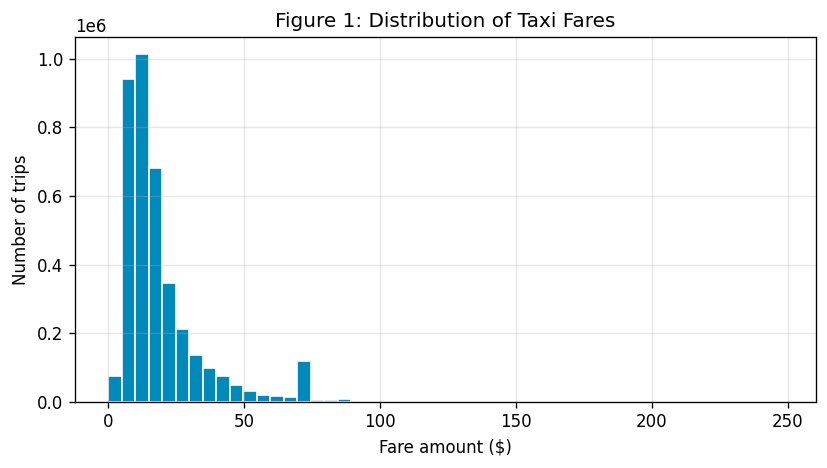

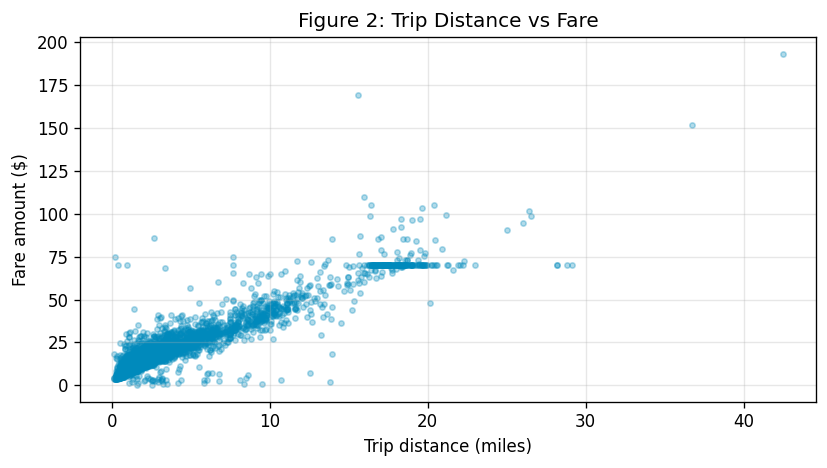

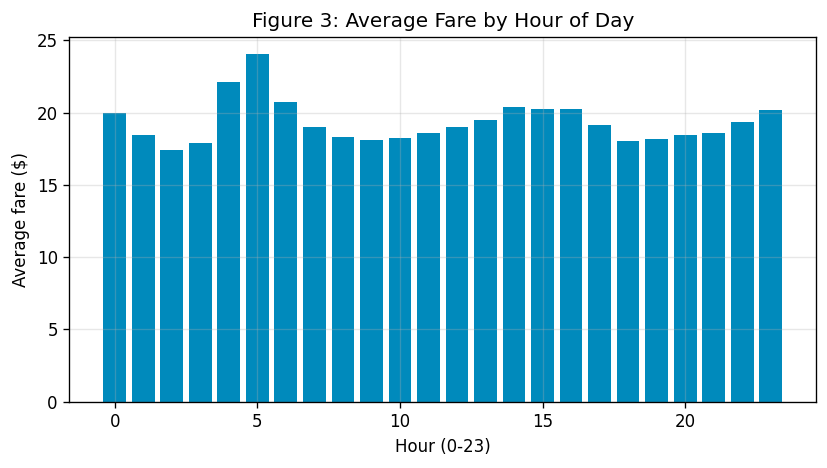

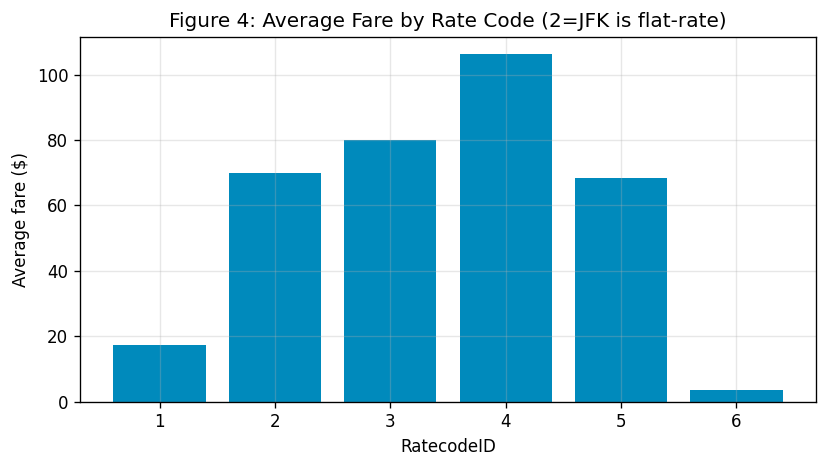

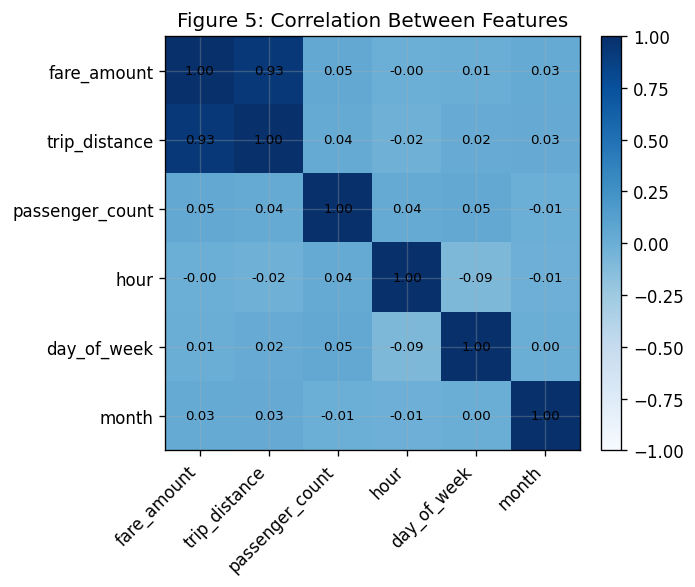

In [7]:
# ----- Build time features from the pickup time -----
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
df["month"] = df["tpep_pickup_datetime"].dt.month

# ----- TABLE 2 - Summary statistics of key columns -----
summary = df[["fare_amount", "trip_distance", "passenger_count"]].describe().round(2)
print("Summary statistics:")
print(summary)

# ----- FIGURE 1 - Distribution of fare amount -----
plt.figure(figsize=(7, 4))
plt.hist(df["fare_amount"], bins=50, color=BAR_COLOR, edgecolor="white")
plt.title("Figure 1: Distribution of Taxi Fares")
plt.xlabel("Fare amount ($)")
plt.ylabel("Number of trips")
plt.tight_layout()
plt.savefig("fig1_fare_distribution.png")
plt.show()

# ----- FIGURE 2 - Trip distance vs fare (the key relationship) -----
samp = df.sample(min(5000, len(df)), random_state=42)   # sample to keep the plot readable
plt.figure(figsize=(7, 4))
plt.scatter(samp["trip_distance"], samp["fare_amount"],
            alpha=0.3, s=10, color=BAR_COLOR)
plt.title("Figure 2: Trip Distance vs Fare")
plt.xlabel("Trip distance (miles)")
plt.ylabel("Fare amount ($)")
plt.tight_layout()
plt.savefig("fig2_distance_vs_fare.png")
plt.show()

# ----- Cell 10: FIGURE 3 - Average fare by hour of day -----
fare_by_hour = df.groupby("hour")["fare_amount"].mean()
plt.figure(figsize=(7, 4))
plt.bar(fare_by_hour.index, fare_by_hour.values, color=BAR_COLOR)
plt.title("Figure 3: Average Fare by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Average fare ($)")
plt.tight_layout()
plt.savefig("fig3_fare_by_hour.png")
plt.show()

# ----- FIGURE 4 - Average fare by rate code -----
fare_by_rate = df.groupby("RatecodeID")["fare_amount"].mean()
plt.figure(figsize=(7, 4))
plt.bar(fare_by_rate.index.astype(str), fare_by_rate.values, color=BAR_COLOR)
plt.title("Figure 4: Average Fare by Rate Code (2=JFK is flat-rate)")
plt.xlabel("RatecodeID")
plt.ylabel("Average fare ($)")
plt.tight_layout()
plt.savefig("fig4_fare_by_ratecode.png")
plt.show()

# ----- FIGURE 5 - Correlation heatmap -----
cols = ["fare_amount", "trip_distance", "passenger_count", "hour", "day_of_week", "month"]
corr = df[cols].corr()

plt.figure(figsize=(6, 5))
im = plt.imshow(corr, cmap="Blues", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols)
# write the number in each cell
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)
plt.title("Figure 5: Correlation Between Features")
plt.tight_layout()
plt.savefig("fig5_correlation.png")
plt.show()

In [8]:
# ----- Choose features and target -----
# Target = the base meter fare. We do NOT use total_amount,
# because that already includes tips, tolls and surcharges (that would be cheating).
target = "fare_amount"

# RatecodeID is a category (the codes are labels, not a scale),
# so we one-hot encode it into separate yes/no columns.
num_features = ["trip_distance", "passenger_count", "hour", "day_of_week", "month"]

X = df[num_features].copy()
X = pd.concat([X, pd.get_dummies(df["RatecodeID"], prefix="rate")], axis=1)
y = df[target]

feature_cols = X.columns.tolist()   # we save this exact order for the frontend
print("Features used:")
print(feature_cols)


Features used:
['trip_distance', 'passenger_count', 'hour', 'day_of_week', 'month', 'rate_1', 'rate_2', 'rate_3', 'rate_4', 'rate_5', 'rate_6']


In [9]:
# ----- Split into training and testing sets -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train rows:", len(X_train), " Test rows:", len(X_test))

Train rows: 3085807  Test rows: 771452


In [10]:
# ----- Baseline model - Linear Regression -----
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
print(f"Linear Regression  ->  RMSE: {lr_rmse:.2f}   R2: {lr_r2:.3f}  MAE: {lr_mae:.4f}")

Linear Regression  ->  RMSE: 5.22   R2: 0.889  MAE: 3.2573


In [11]:
# ----- Cell 9: Stronger model - Random Forest -----
# rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf = RandomForestRegressor(
    n_estimators=50,     
    max_depth=20,        
    n_jobs=2,            
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
print(f"Random Forest      ->  RMSE: {rf_rmse:.2f}   R2: {rf_r2:.3f} MAE: {rf_mae:.4f} ")

Random Forest      ->  RMSE: 4.53   R2: 0.916 MAE: 2.6629 


In [12]:
# ----- TABLE 3 - Model comparison (shows which is better) -----
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [round(lr_rmse, 2), round(rf_rmse, 2)],
    "MAE": [round(lr_mae, 2), round(rf_mae, 2)],
    "R2": [round(lr_r2, 3), round(rf_r2, 3)]
})
print("Model comparison (lower RMSE, Lower MAE and higher R2 = better):")
print(results.to_string(index=False))
results.to_csv("model_comparison.csv", index=False)

Model comparison (lower RMSE, Lower MAE and higher R2 = better):
            Model  RMSE  MAE    R2
Linear Regression  5.22 3.26 0.889
    Random Forest  4.53 2.66 0.916


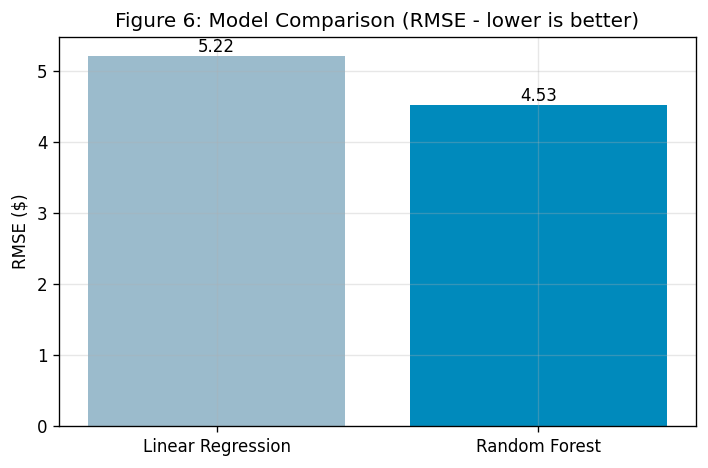

In [13]:
# ----- FIGURE 6 - Model comparison bar chart -----
plt.figure(figsize=(6, 4))
plt.bar(results["Model"], results["RMSE"], color=["#9bbbcc", "#008ABC"])
plt.title("Figure 6: Model Comparison (RMSE - lower is better)")
plt.ylabel("RMSE ($)")
for i, v in enumerate(results["RMSE"]):
    plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("fig6_model_comparison.png")
plt.show()

In [14]:
# ----- Save the better Model -----
if rf_rmse <= lr_rmse:
    best_model, best_name = rf, "Random Forest"
else:
    best_model, best_name = lr, "Linear Regression"

best_pred = best_model.predict(X_test)
print(f"Best model: {best_name}")

# Save the model AND the feature order together in one file.
joblib.dump({"model": best_model, "features": feature_cols}, "fare_model.pkl")
print("Saved fare_model.pkl to the Output folder.")

Best model: Random Forest
Saved fare_model.pkl to the Output folder.


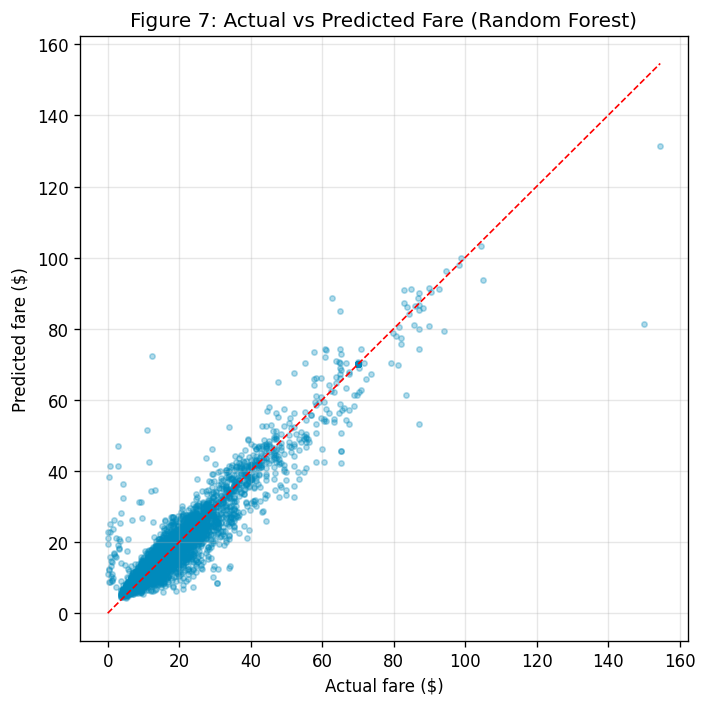

In [15]:
# ----- FIGURE 7 - Actual vs predicted fares (best model) -----
samp_idx = np.random.RandomState(42).choice(len(y_test), min(5000, len(y_test)), replace=False)
plt.figure(figsize=(6, 6))
plt.scatter(np.array(y_test)[samp_idx], best_pred[samp_idx],
            alpha=0.3, s=10, color=BAR_COLOR)
lims = [0, max(np.array(y_test)[samp_idx].max(), best_pred[samp_idx].max())]
plt.plot(lims, lims, "r--", linewidth=1)   # perfect-prediction line
plt.title(f"Figure 7: Actual vs Predicted Fare ({best_name})")
plt.xlabel("Actual fare ($)")
plt.ylabel("Predicted fare ($)")
plt.tight_layout()
plt.savefig("fig7_actual_vs_predicted.png")
plt.show()

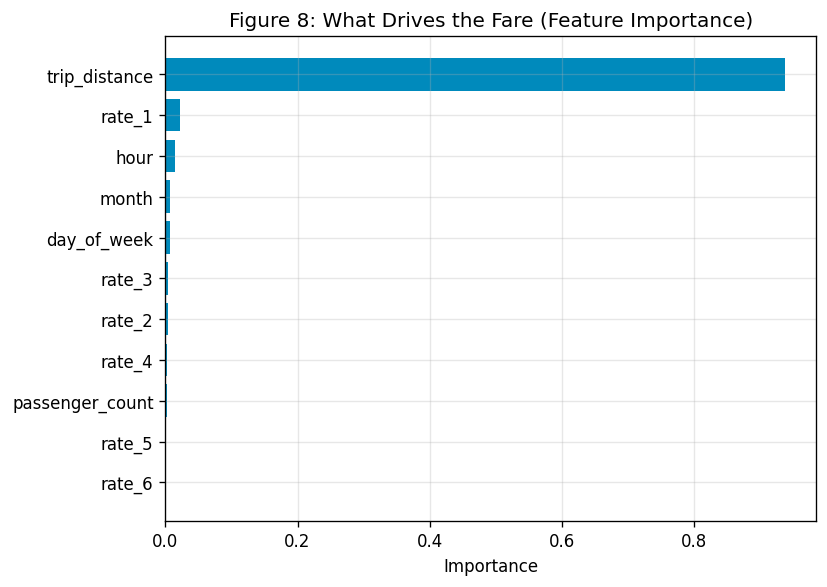

trip_distance      9.370594e-01
rate_1             2.234159e-02
hour               1.412899e-02
month              7.147451e-03
day_of_week        6.709448e-03
rate_3             3.576141e-03
rate_2             3.477375e-03
rate_4             2.045355e-03
passenger_count    1.950874e-03
rate_5             1.563417e-03
rate_6             1.296990e-09
dtype: float64


In [16]:
# ----- FIGURE 8 - Feature importance (Random Forest only) -----
if best_name == "Random Forest":
    importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
    plt.figure(figsize=(7, 5))
    plt.barh(importances.index, importances.values, color=BAR_COLOR)
    plt.title("Figure 8: What Drives the Fare (Feature Importance)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("fig8_feature_importance.png")
    plt.show()
    print(importances.sort_values(ascending=False))
else:
    print("Feature importance is only available for the Random Forest model.")

In [20]:
# ----- Cell 22: Test the saved model with own input -----
import joblib
# import pandas as pd

saved = joblib.load("fare_model.pkl")
model = saved["model"]
feature_cols = saved["features"]

def predict_fare(trip_distance, passenger_count, hour, day_of_week, month, ratecode):
    row = {
        "trip_distance": trip_distance,
        "passenger_count": passenger_count,
        "hour": hour,
        "day_of_week": day_of_week,   # 0 = Monday ... 6 = Sunday
        "month": month,
    }
    row[f"rate_{ratecode}"] = 1
    X_new = pd.DataFrame([row]).reindex(columns=feature_cols, fill_value=0)
    return model.predict(X_new)[0]


fare = predict_fare(
    trip_distance=3.5,
    passenger_count=2,
    hour=18,
    day_of_week=4,
    month=6,
    ratecode=1
)
print(f"Predicted fare: ${fare:.2f}")

Predicted fare: $23.62
